<center><h1>Kim_Beomjun_HW2</h1></center>
<br>
<br>

Name: Beomjun Kim 
<br>
Github Username: valen991693
<br>
USC ID: 4391-4935-38

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [ ]:
file_path = "../data/Folds5x2_pp.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

Shape: (9568, 5)

Columns:
['AT', 'V', 'AP', 'RH', 'PE']

First 5 rows:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


The dataset contains 9,568 rows and 5 columns.

Each row represents one hourly observation collected from the combined cycle power plant under full-load operation.

The columns represent four predictor variables and one response variable:

- AT: Ambient Temperature
- V: Exhaust Vacuum
- AP: Ambient Pressure
- RH: Relative Humidity
- PE: Electrical Power Output

The first four variables are used as predictors, while PE is the response variable to be predicted.

#### ii. pairwise scatterplots of all the varianbles

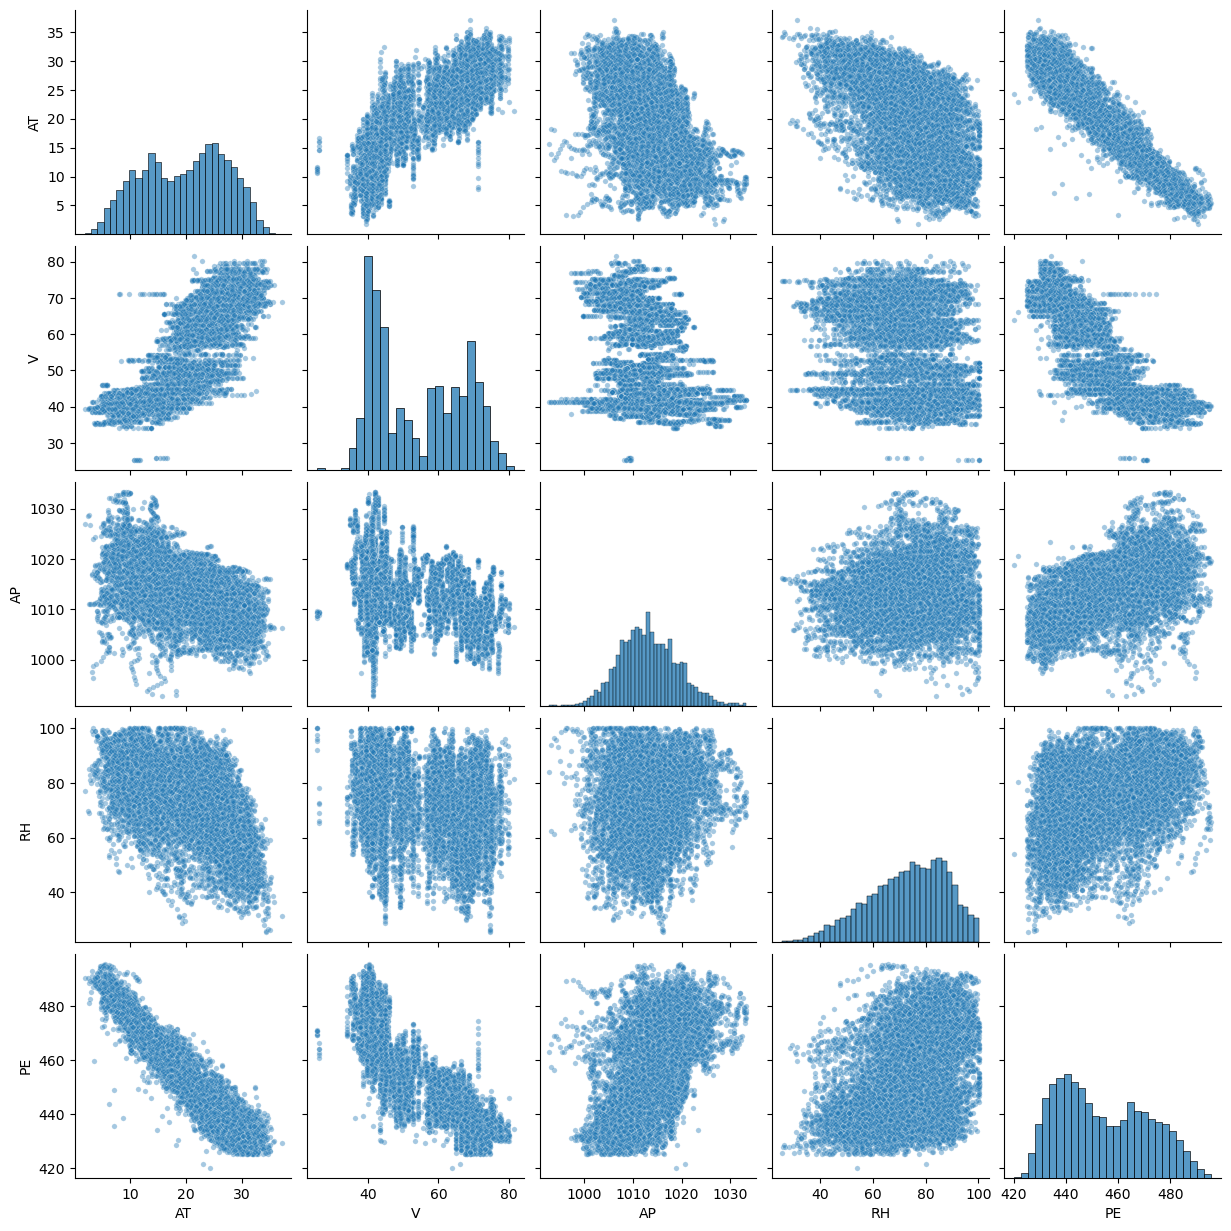

In [4]:
sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.show()

The pairwise scatterplots show several clear relationships among the variables.

PE has a strong negative association with AT and V. As ambient temperature or exhaust vacuum increases, the electrical power output generally decreases. The relationship between AT and PE appears particularly strong and approximately linear.

AP and RH show weaker positive associations with PE compared with AT and V.

There are also noticeable relationships among the predictor variables. In particular, AT and V are strongly positively associated, indicating that the predictors are not independent.

Overall, AT and V appear to have the strongest individual relationships with PE, while AP and RH have weaker relationships with the response.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


The table summarizes the central tendency and spread of each variable.

AT, V, AP, RH, and PE all show moderate variation across the observations. The mean and median values are relatively close for most variables, suggesting that the distributions are not extremely skewed. The IQR provides the spread of the middle 50% of the observations and is less sensitive to extreme values than the full range.

### (c) Simple Linear Regression

In [6]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df["PE"]

    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_df = pd.DataFrame(simple_results)
simple_results_df.round(3)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.034,-2.171,0.0,0.899
1,V,517.802,-1.168,0.0,0.757
2,AP,-1055.261,1.490,0.0,0.269
3,RH,420.962,0.456,0.0,0.152


#### Regression plots

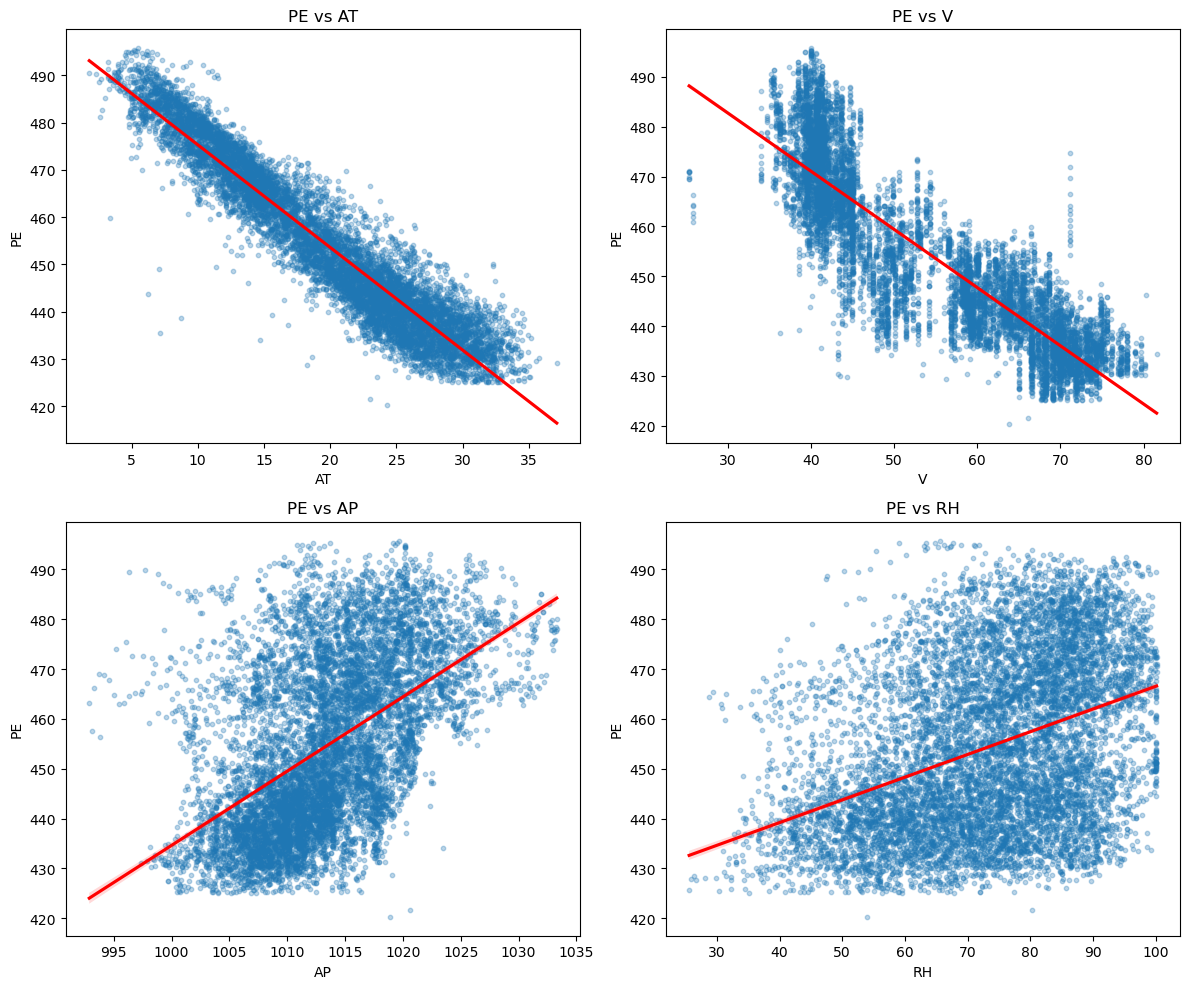

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        scatter_kws={"alpha": 0.3, "s": 10},
        line_kws={"color": "red"},
        ax=ax
    )

    ax.set_title(f"PE vs {predictor}")

plt.tight_layout()
plt.show()

#### Outliers

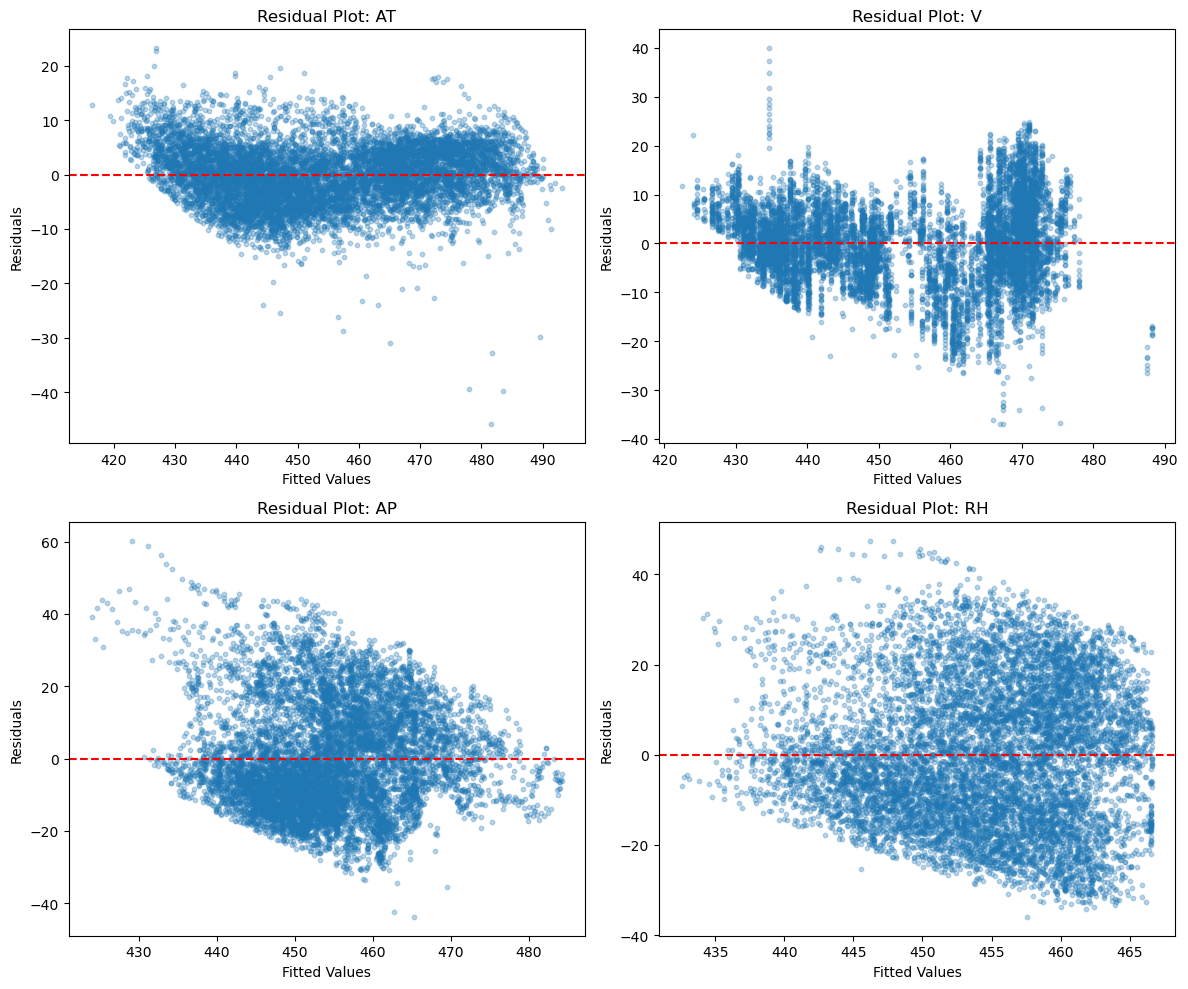

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    model = simple_models[predictor]

    ax.scatter(
        model.fittedvalues,
        model.resid,
        alpha=0.3,
        s=10
    )

    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residual Plot: {predictor}")

plt.tight_layout()
plt.show()

All four predictors have statistically significant associations with PE in the
simple linear regression models (p < 0.001).

AT has the strongest individual linear relationship with PE. Its estimated
coefficient is approximately -2.171, indicating that a one-degree increase in
ambient temperature is associated with an approximately 2.17 MW decrease in
predicted electrical power output. The model has an R-squared of approximately
0.899.

V also has a strong negative association with PE, with an estimated coefficient
of approximately -1.168 and an R-squared of approximately 0.757.

AP and RH both have positive and statistically significant associations with PE,
but their R-squared values are considerably smaller, approximately 0.269 and
0.152, respectively. Thus, although these associations are statistically
significant, AP and RH individually explain much less variation in PE than AT
and V.

The scatterplots and fitted regression lines support these findings. Some
observations have relatively large residuals, but there is no clear evidence
that they are erroneous observations. Therefore, I would not remove observations
solely on the basis of these simple regression plots.

### (d) Multiple Regression

In [9]:
X = df[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)

y = df["PE"]

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:50:18   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The multiple linear regression model using all four predictors has an R-squared
of approximately 0.929, indicating that about 92.9% of the variation in PE is
explained by AT, V, AP, and RH together.

The estimated coefficients are approximately -1.978 for AT, -0.234 for V,
0.062 for AP, and -0.158 for RH.

All four predictors have p-values below 0.001. Therefore, we can reject
\(H_0: \beta_j = 0\) for AT, V, AP, and RH, indicating that each predictor has
a statistically significant association with PE after controlling for the other
predictors.

AT has the largest negative coefficient in the fitted model. One notable result
is that the coefficient of RH is negative in the multiple regression model,
whereas it was positive in the simple regression model. This difference reflects
the effect of controlling for the other predictors.

### (e) 1c Compare to 1d

In [10]:
simple_coefs = simple_results_df.set_index("Predictor")["Coefficient"]

multiple_coefs = multiple_model.params[["AT", "V", "AP", "RH"]]

coef_comparison = pd.DataFrame({
    "Simple Regression": simple_coefs,
    "Multiple Regression": multiple_coefs
})

coef_comparison

,Simple Regression,Multiple Regression
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


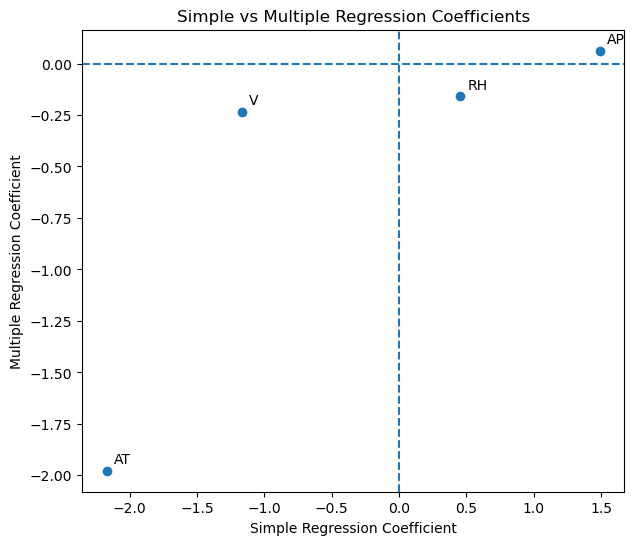

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(
    coef_comparison["Simple Regression"],
    coef_comparison["Multiple Regression"]
)

for predictor in coef_comparison.index:
    plt.annotate(
        predictor,
        (
            coef_comparison.loc[predictor, "Simple Regression"],
            coef_comparison.loc[predictor, "Multiple Regression"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

plt.show()

The regression coefficients differ noticeably between the simple and multiple
regression models.

AT remains strongly negative in both models, although its magnitude becomes
slightly smaller in the multiple regression model. The coefficient for V also
remains negative but decreases substantially in magnitude.

The coefficient for AP decreases from a relatively large positive value in the
simple regression model to a value close to zero in the multiple regression
model. RH shows the largest qualitative change, switching from a positive
coefficient in the simple regression model to a negative coefficient in the
multiple regression model.

These differences occur because the predictors are correlated with one another.
Simple regression measures the association between one predictor and PE without
controlling for the other variables, while multiple regression estimates the
association of each predictor with PE while holding the remaining predictors
constant.

### (f) Nonlinear Association

In [12]:
predictors = ["AT", "V", "AP", "RH"]

nonlinear_results = []

for predictor in predictors:
    X = pd.DataFrame({
        predictor: df[predictor],
        f"{predictor}^2": df[predictor] ** 2,
        f"{predictor}^3": df[predictor] ** 3
    })

    X = sm.add_constant(X)
    y = df["PE"]

    model = sm.OLS(y, X).fit()

    nonlinear_results.append({
        "Predictor": predictor,
        "Linear p-value": model.pvalues[predictor],
        "Quadratic p-value": model.pvalues[f"{predictor}^2"],
        "Cubic p-value": model.pvalues[f"{predictor}^3"],
        "R-squared": model.rsquared
    })

nonlinear_results_df = pd.DataFrame(nonlinear_results)

nonlinear_results_df

,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


There is evidence of nonlinear association between the predictors and PE.

For AT, both the quadratic and cubic terms are highly statistically significant
(p < 0.001), providing strong evidence of nonlinearity.

For V, the quadratic term is not statistically significant (p ≈ 0.768), while
the cubic term is statistically significant (p ≈ 0.014). Therefore, there is
some evidence of nonlinear association between V and PE.

For AP, both the quadratic and cubic terms are highly statistically significant
(p < 0.001), indicating evidence of nonlinearity.

For RH, both the quadratic and cubic terms are also statistically significant
(p < 0.001), indicating evidence of nonlinearity.

Overall, all four predictors show some evidence of nonlinear association with PE,
although the evidence for V is weaker than for the other predictors.

### (g) Interactions of Predictors

In [13]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:50:19   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

The full linear regression model includes all four main effects and all six
possible pairwise interaction terms.

At the 0.05 significance level, the interaction terms AT:V, AT:RH, V:AP,
and AP:RH are statistically significant. In contrast, AT:AP and V:RH are
not statistically significant.

Therefore, there is evidence that the association between some predictors
and PE depends on the values of other predictors. For example, the significant
AT:V interaction suggests that the relationship between ambient temperature
and electrical power output varies with exhaust vacuum.

### (h) Improvement

#### Train-test split

In [14]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

#### Baseline linear regression

In [15]:
baseline_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_df
).fit()

baseline_train_pred = baseline_model.predict(train_df)
baseline_test_pred = baseline_model.predict(test_df)

baseline_train_mse = mean_squared_error(
    train_df["PE"],
    baseline_train_pred
)

baseline_test_mse = mean_squared_error(
    test_df["PE"],
    baseline_test_pred
)

print("Baseline Train MSE:", baseline_train_mse)
print("Baseline Test MSE:", baseline_test_mse)

Baseline Train MSE: 20.58083972573871
Baseline Test MSE: 21.239856938225284


#### Full model: quadratic + interactions

In [16]:
full_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
       + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:AP + AT:RH
       + V:AP + V:RH
       + AP:RH
    """,
    data=train_df
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:50:19   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

#### Reduced improved model

In [17]:
improved_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
       + I(AT**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:AP + AT:RH
       + AP:RH
    """,
    data=train_df
).fit()

print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:50:19   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.0

#### Reduced improved model

In [18]:
improved_model = smf.ols(
    """
    PE ~ AT + V + AP + RH
       + I(AT**2) + I(AP**2) + I(RH**2)
       + AT:V + AT:AP + AT:RH
       + AP:RH
    """,
    data=train_df
).fit()

print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:50:19   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.0

#### Improved model MSE

In [19]:
improved_train_pred = improved_model.predict(train_df)
improved_test_pred = improved_model.predict(test_df)

improved_train_mse = mean_squared_error(
    train_df["PE"],
    improved_train_pred
)

improved_test_mse = mean_squared_error(
    test_df["PE"],
    improved_test_pred
)

print("Improved Train MSE:", improved_train_mse)
print("Improved Test MSE:", improved_test_mse)

Improved Train MSE: 17.89084277318531
Improved Test MSE: 18.66004049510709


In [20]:
mse_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Interaction + Quadratic Regression"
    ],
    "Train MSE": [
        baseline_train_mse,
        improved_train_mse
    ],
    "Test MSE": [
        baseline_test_mse,
        improved_test_mse
    ]
})

mse_comparison

,Model,Train MSE,Test MSE
0,Linear Regression,20.580840,21.239857
1,Interaction + Quadratic Regression,17.890843,18.660040


The data were randomly split into 70% training data and 30% test data.

The baseline multiple linear regression model using AT, V, AP, and RH produced
a training MSE of approximately 20.581 and a test MSE of approximately 21.240.

I then fitted a model containing all pairwise interaction terms and quadratic
terms. Insignificant higher-order terms were removed based on their p-values,
while preserving the hierarchy of the model. In particular, a main effect was
retained whenever it was involved in a significant interaction or nonlinear
term.

The reduced model retained the quadratic terms for AT, AP, and RH and the
interaction terms AT:V, AT:AP, AT:RH, and AP:RH.

The improved model produced a training MSE of approximately 17.891 and a test
MSE of approximately 18.660. Both values are lower than those of the baseline
linear regression model.

Therefore, incorporating nonlinearities and interaction effects improves the
predictive performance of the linear regression model on this train-test split.

### (i) KNN

In [21]:
X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

normalized_train_mse = []
normalized_test_mse = []

#### Raw features

In [22]:
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

#### Normalized features

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    normalized_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    normalized_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

#### Finding best k

In [24]:
best_raw_k = k_values[np.argmin(raw_test_mse)]
best_normalized_k = k_values[np.argmin(normalized_test_mse)]

print("Best k for raw features:", best_raw_k)
print("Best raw test MSE:", min(raw_test_mse))

print("\nBest k for normalized features:", best_normalized_k)
print("Best normalized test MSE:", min(normalized_test_mse))

Best k for raw features: 5
Best raw test MSE: 15.726819842563568

Best k for normalized features: 4
Best normalized test MSE: 14.305669422675024


#### Plot: errors versus 1/k

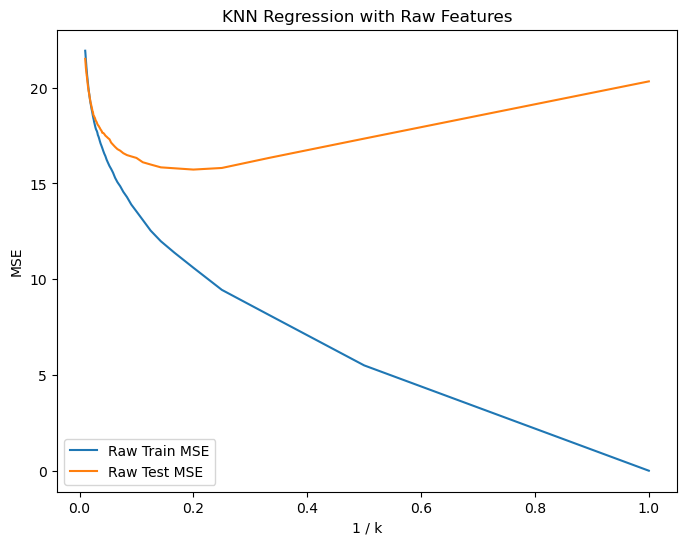

In [25]:
inverse_k = 1 / np.array(list(k_values))

plt.figure(figsize=(8, 6))

plt.plot(
    inverse_k,
    raw_train_mse,
    label="Raw Train MSE"
)

plt.plot(
    inverse_k,
    raw_test_mse,
    label="Raw Test MSE"
)

plt.xlabel("1 / k")
plt.ylabel("MSE")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.show()

For KNN regression, I evaluated values of k from 1 to 100 using both the
original features and standardized features.

Using the raw features, the minimum test MSE was approximately 15.727 at
k = 5.

After standardizing the predictors, the minimum test MSE decreased to
approximately 14.306 at k = 4. The corresponding training MSE was
approximately 8.591.

The normalized features produced better test performance than the raw
features. This is expected because KNN is based on distances between
observations and is therefore sensitive to differences in predictor scales.
Standardization puts the predictors on comparable scales so that variables
with larger numerical ranges do not dominate the distance calculation.

### (j ) Compare KNN and Linear

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Best Linear Regression Model",
        "Best KNN Regression Model"
    ],
    "Test MSE": [
        improved_test_mse,
        min(normalized_test_mse)
    ]
})

comparison

,Model,Test MSE
0,Best Linear Regression Model,18.660040
1,Best KNN Regression Model,14.305669


In [27]:
improvement = (
    (improved_test_mse - min(normalized_test_mse))
    / improved_test_mse
) * 100

print(f"KNN reduces test MSE by approximately {improvement:.2f}% compared with the best linear model.")

KNN reduces test MSE by approximately 23.34% compared with the best linear model.


The best linear regression model was the model including selected interaction
terms and quadratic nonlinearities. Its test MSE was approximately 18.660.

The best KNN regression model used standardized predictors with k = 4 and
achieved a lower test MSE of approximately 14.306.

Therefore, the KNN regression model performed better on the test data for this
train-test split.

This result suggests that the relationship between the predictors and PE is not
fully captured by the linear regression model, even after adding selected
interaction and quadratic terms. KNN is a more flexible, local method and can
adapt to nonlinear patterns in the data.

Standardization was also important for KNN because the method is based on
distances between observations and the predictors are measured on different
scales.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would generally perform better.

Because the sample size is extremely large relative to the number of predictors,
a flexible method can estimate a more complex relationship without suffering
too much from high variance or overfitting. Therefore, the lower bias of a
flexible method can be advantageous.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would generally perform worse.

When the number of predictors is very large relative to the number of
observations, a flexible method is likely to have high variance and overfit the
training data. A less flexible method would generally be more stable and may
generalize better to new observations.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would generally perform better.

If the true relationship between the predictors and the response is highly
nonlinear, an inflexible method may have high bias because it cannot adequately
capture the complex pattern. A flexible method can adapt more closely to the
nonlinear relationship.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would generally perform worse.

When the variance of the error terms is extremely high, there is a large amount
of irreducible noise in the data. A flexible method may fit this noise rather
than the underlying signal, leading to high variance and overfitting. A less
flexible method would generally be preferable.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distances from the test point (0, 0, 0) are:

- Observation 1: 3
- Observation 2: 2
- Observation 3: sqrt(10) ≈ 3.162
- Observation 4: sqrt(5) ≈ 2.236
- Observation 5: sqrt(2) ≈ 1.414
- Observation 6: sqrt(3) ≈ 1.732

### (b) What is our prediction with K = 1? Why?

For K = 1, the prediction is Green because Observation 5 is the closest
training observation to the test point, with distance sqrt(2).

### (c) What is our prediction with K = 3? Why?

For K = 3, the three nearest observations are Observations 5, 6, and 2.

Their classes are Green, Red, and Red, respectively. Since Red is the majority
class among the three nearest neighbors, the prediction is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would generally expect a small value of K to perform better.

A small K produces a more flexible decision boundary, which can adapt to a
highly nonlinear Bayes decision boundary. A large K produces a smoother and
less flexible boundary, which may fail to capture complex local structure.